In [ ]:
# In general, this notebook uses two sets of data, generated and reconstructed, to determine acceptance
# in each w-q2 bin. The gen and rec csv files (excel would also work) are loaded into the notebook
# and the data is put into respective w-q2 bins. The histograms created for gen and rec are divided to find
# acceptance (acc = rec/gen) and other various calculations are performed. Acceptance is plotted 
# against the w-q2 bins in x and y, with acceptance represented in the z direction via color bar. Other
# histograms follow in similar format, replacing acceptance with integrated cross section, luminosity, etc.

# load necessary things

In [174]:
# load things to make science happen
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.pyplot
import matplotlib.cm
import math
import sys
import csv
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe

In [155]:
# read in the csv files
sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/twopeg/fall18_inb/10_6gen_excl_fa18inb_jlab_01_21_2026.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/pass2noBG/10_6gen_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6gen_excl_testweight_jlab_12_02_2024.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/10_6gen_excl_fa18outb_jlab_12_11_2025.csv", index_col=False)
# sim_gen_10_6GeV = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/exp/10_6exp_excl_jlab_11_09_2025.csv", index_col=False)
sim_gen_10_6GeV = sim_gen_10_6GeV[(sim_gen_10_6GeV.weight>0.0)]

sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/twopeg/fall18_inb/10_6rec_excl_fa18inb_jlab_01_16_2026.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/pass2noBG/10_6rec_excl_pass2noBG_jlab_12_02_2024.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6rec_excl_testweight_jlab_12_02_2024.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/10_6rec_excl_fa18outb_jlab_2_12_11_2025.csv",  index_col=False)
# sim_rec_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/notebooks/notebook_csvs/experiment/EXCL_topology/binned_wq2/MM2_signal_background/all_signal_events.csv",  index_col=False)
sim_rec_10_6GeV = sim_rec_10_6GeV[(sim_rec_10_6GeV.weight>0.0)]

# load 22 GeV generated and reconstructed .csv files 
sim_gen_22GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/22GeV/pass2noBG/22gen_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)
sim_gen_22GeV = sim_gen_22GeV[(sim_gen_22GeV.weight>0.0)]

sim_rec_22GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/22GeV/pass2noBG/22rec_excl_pass2noBG_jlab_12_02_2024.csv",  index_col=False)
sim_rec_22GeV = sim_rec_22GeV[(sim_rec_22GeV.weight>0.0)]

# options are fall18_inb, fall18_outb, 22gev_sim so far
data_name = "fall18_inb"

beam_energy = 10.6
# beam_energy = 22.0

hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists/simulation/{data_name}/EXCL_topology')


In [156]:
# remove event colummn now
sim_gen_22GeV.drop(columns=['event'], inplace=True, errors='ignore')
sim_rec_22GeV.drop(columns=['event'], inplace=True, errors='ignore')

sim_gen_10_6GeV = sim_gen_10_6GeV.rename(columns={"w": "w_mc"})
sim_gen_10_6GeV = sim_gen_10_6GeV.rename(columns={"q2": "q2_mc"})

sim_gen_10_6GeV["weight"] = sim_gen_10_6GeV["weight"]*1e4
# sim_gen_22GeV["weight"] = sim_gen_22GeV["weight"]*1e4


In [157]:
# change these to be for 10.6 or 22 GeV

sim_gen_dataset = sim_gen_10_6GeV
sim_rec_dataset = sim_rec_10_6GeV

# sim_gen_dataset = sim_gen_22GeV
# sim_rec_dataset = sim_rec_22GeV

In [158]:
# checking that my files read in correctly
sim_gen_dataset.head(16)

,event,w_mc,q2_mc,weight
0,0,2.530639,2.805493,5.725293
1,1,1.498349,10.833160,0.007551
2,2,2.152088,10.605420,0.031070
3,3,2.510481,2.312317,4.937897
4,4,1.694629,7.585569,0.028363
5,5,1.446420,1.758805,9.195650
6,6,1.335861,3.579010,0.035746
7,7,2.478888,4.856726,0.398933
8,8,1.905790,8.304357,0.078627
9,9,2.399059,2.382088,2.495829


In [159]:
sim_gen_dataset.tail(3)

,event,w_mc,q2_mc,weight
9964997,9964997,1.633100,10.411410,0.003814
9964998,9964998,1.436276,11.953020,0.000598
9964999,9964999,2.561290,3.784178,1.273575


In [160]:
sim_rec_dataset.head(6)

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,15,2.458661,3.441023,0.795051,0.115348,0.062065,1.496857,-0.000280,2.688281,2.275032,...,0.430666,11.87184,14.63208,6.733225,9.855906,30.19408,45.44140,2.809084,3.123626,15.250710
1,34,2.364093,5.805726,0.192738,0.014239,0.017385,0.917695,-0.000171,0.665193,0.646256,...,0.019637,39.57890,39.13470,16.431680,16.062460,22.98981,23.05962,0.454234,0.392217,0.241355
2,46,1.862503,4.462643,2.158529,0.032788,0.023614,0.892529,-0.000061,1.739021,1.747139,...,0.008930,23.99844,24.09138,48.239340,48.152580,23.77730,23.80910,0.122310,0.296931,0.129262
3,53,1.678796,4.639885,0.906918,-0.006919,-0.033035,0.824061,-0.003638,0.769281,0.701962,...,0.077756,29.97955,28.67951,23.455730,22.630840,31.69822,31.16652,3.034274,1.487918,1.051008
4,75,1.448413,4.369272,0.087426,-0.013796,0.009131,0.825377,-0.003635,1.053332,1.053255,...,0.062305,37.50144,34.40286,29.483980,23.693270,30.30650,28.59624,3.389663,5.971719,1.739331
5,87,1.477553,3.118888,3.462691,0.012468,0.012525,0.871423,-0.000117,0.970631,0.969030,...,0.010985,31.47717,30.83527,50.427830,49.326370,28.76250,28.39155,0.642077,1.123485,0.409599


In [161]:
sim_rec_dataset.tail(3)

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
538119,9964924,2.470309,7.457703,0.054630,-0.094357,0.000709,0.704289,-0.007192,1.612349,1.579289,...,0.084847,24.70393,21.90168,71.52242,70.43009,11.82711,11.14962,2.805995,11.754250,0.854016
538120,9964934,1.951514,6.621606,0.036798,0.328850,0.309116,1.771767,0.026248,1.539515,1.170781,...,0.434562,15.84917,24.48708,20.71520,32.98003,15.22426,19.05001,9.825768,13.991600,3.883352
538121,9964958,1.704074,5.697740,0.164413,0.014000,0.006054,0.839937,-0.000765,0.314244,0.284549,...,0.033463,60.87459,63.73955,19.99331,20.46642,23.16781,23.33052,2.956069,1.249139,0.350181


# define W-Q² bins

In [162]:
# w-q2 ranges
sim_10_6gev_q2bins = np.arange(2.0, 11.1, 0.5)
sim_22gev_q2bins = np.arange(2.0, 30.1, 0.5)

sim_10_6gev_q2bins_fixed = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,12.0]
sim_22gev_q2bins_fixed = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,25.0,30.0]

sim_10_6gev_q2bins_plotting = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0]
sim_22gev_q2bins_plotting = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,25.0,30.0]

# should be sim_10_6gev_q2bins or sim_22gev_q2bins
bin_y = sim_10_6gev_q2bins
bin_x = np.arange(1.4, 2.451, 0.05)

major_xticks = np.round(np.arange(1.4, 2.45 + 1e-6, 0.1), 2)
sim_22_major_yticks = np.arange(2.0, 30.1, 2.0)
sim_10_6_major_yticks = np.arange(2.0, 11.1, 1.0)

major_yticks = sim_10_6_major_yticks

q2_min, q2_max = 1.6, 12.0
# q2_min, q2_max = 1.6, 22.0

# bin generated events

In [163]:
# find number of generated events in each w-q2 bin from 10.6 GeV simulations (w and q2 are my x and y values)
def calcFunc(df):
    gen=df

    with open('output_gen.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val','q2_val','gen_events' ,'flux','weight','cross_section','formfactor','formfactor_krishna','cs_scaled','cs_scaled_krishna','cs_scaled_unc','cs_scaled_krishna_unc','cs_unc'])
        NSIGMA = 4
        cut_data = {}
    
        # Make w bins
        w_bin_ranges = bin_x
        
        # Cuts the generated w data into the ranges from above
        gen['w_bin'] = pd.cut(gen.w_mc, w_bin_ranges)
        # unique_w = gen.w_bin.unique()
        # unique_w = pd.Index.sort_values(unique_w)
        # unique_w = unique_w.dropna()
        unique_w = gen['w_bin'].cat.categories

        # Make q2 bins
        # q2_bin_ranges = bin_y
        
        # Cuts the gen q2 data into the ranges from above
        gen['q2_bin'] = pd.cut(gen.q2_mc, bin_y)
        # unique_q2 = gen.q2_bin.unique()
        # unique_q2 = pd.Index.sort_values(unique_q2)
        # unique_q2 = unique_q2.dropna()
        unique_q2 = gen['q2_bin'].cat.categories

        
        # function to calculate virtual photon flux
        def flux(w,q2_value):
            E_beam = beam_energy
            MASS_P = 0.938;
            PI = 3.14159265358979323846;

            omega = (w * w + q2_value - MASS_P * MASS_P) / (2. * MASS_P);

            en_elp = E_beam - omega;
            th_elp = 2 * math.asin(math.sqrt(q2_value / 4. / E_beam / en_elp));

            epsilon = 1 / (1. + 2. * (1. + omega * omega / q2_value) * (math.tan(th_elp / 2.)) * (math.tan(th_elp / 2.)));

            flux_calc = (omega - q2_value / 2. / MASS_P) / 137.;

            flux_calc = flux_calc / 2. / (PI) / E_beam / q2_value / (1 - epsilon);
            flux_calc = flux_calc * w / E_beam / MASS_P;

            return flux_calc;
             
        # go through each w-q2 bin
        for w in unique_w:
            for q2 in unique_q2:
                data = gen[(gen.w_bin == w) & (gen.q2_bin == q2)]
                w_val = (w.right+w.left)/2.0
                q2_val = (q2.right+q2.left)/2.0
                virtual_flux = flux(w_val,q2_val)
                ff_scale=(1/(1+(q2_val/0.7))**( 0.31660)) / ((1/(1+0.65/0.7))**(1.18085))
                # Coworker's form-factor scaling
                ff_scale_krishna = (1 / (1 + (q2_val / 0.7))**0.47189) / 0.36314
                index = data.index
                number_of_rows = len(index) 
                # weight_sum=data['weight'].sum()  / 1e4  # divide weight by 10^4 for new weights by krishna ***this is done at the csv file creation level, not in the notebook
                # cs = weight_sum/(number_of_rows*virtual_flux)
                # cs_scaled = cs* ff_scale

                # Apply the 1e4 normalization to the event weights
                weights = data['weight'].to_numpy()  / 1e4

                # Sum of weights
                weight_sum = np.sum(weights)

                # Sum of squared weights
                weight_squared_sum = np.sum(weights**2)

                # Cross section
                cs = weight_sum / (number_of_rows * virtual_flux)

                # Form-factor scaling
                cs_scaled = cs * ff_scale
                cs_scaled_krishna = cs * ff_scale_krishna

                # Statistical uncertainty
                cs_scaled_unc = (
                    np.sqrt(weight_squared_sum)
                    / (number_of_rows * virtual_flux)
                    * ff_scale
                )

                cs_scaled_krishna_unc = (
                    np.sqrt(weight_squared_sum)
                    / (number_of_rows * virtual_flux)
                    * ff_scale_krishna
                )

                cs_unc = (
                    np.sqrt(weight_squared_sum)
                    / (number_of_rows * virtual_flux)
                )
                
                out_binned_exclusive_writer.writerow([w_val, q2_val, number_of_rows, 
                                                          "{:.5f}".format(virtual_flux), 
                                                          "{:.5f}".format(weight_sum), 
                                                          "{:.5f}".format(cs), 
                                                          "{:.5f}".format(ff_scale), 
                                                          "{:.5f}".format(ff_scale_krishna), 
                                                          "{:.5f}".format(cs_scaled),
                                                          "{:.5f}".format(cs_scaled_krishna),
                                                          "{:.5f}".format(cs_scaled_unc),
                                                          "{:.5f}".format(cs_scaled_krishna_unc),
                                                          "{:.5f}".format(cs_unc)])
                    
                print(w_val, q2_val, "{:.7f}".format(virtual_flux), number_of_rows, "{:.5f}".format(weight_sum), "{:.5f}".format(cs), "{:.5f}".format(ff_scale), "{:.5f}".format(ff_scale_krishna),
                       "{:.5f}".format(cs_scaled), "{:.5f}".format(cs_scaled_krishna), "{:.5f}".format(cs_scaled_unc), "{:.5f}".format(cs_scaled_krishna_unc), "{:.5f}".format(cs_unc))

    return cut_data

In [164]:
# calculations for 10.6 GeV generated events
my_output = calcFunc(sim_gen_dataset)

1.4249999999999998 2.25 0.0001475 17325 4.62835 1.81107 1.37731 1.39677 2.49441 2.52965 0.02485 0.02520 0.01804
1.4249999999999998 2.75 0.0000923 17286 1.98222 1.24241 1.31071 1.29729 1.62844 1.61177 0.01603 0.01587 0.01223
1.4249999999999998 3.25 0.0000617 17266 0.96232 0.90355 1.25573 1.21703 1.13462 1.09965 0.01115 0.01081 0.00888
1.4249999999999998 3.75 0.0000433 17286 0.50110 0.67011 1.20923 1.15047 0.81032 0.77095 0.00799 0.00760 0.00661
1.4249999999999998 4.25 0.0000315 17291 0.28626 0.52589 1.16914 1.09409 0.61483 0.57536 0.00605 0.00566 0.00518
1.4249999999999998 4.75 0.0000236 17351 0.17008 0.41551 1.13406 1.04552 0.47121 0.43442 0.00463 0.00427 0.00408
1.4249999999999998 5.25 0.0000181 17508 0.10531 0.33219 1.10298 1.00310 0.36640 0.33322 0.00359 0.00326 0.00325
1.4249999999999998 5.75 0.0000142 17535 0.06819 0.27429 1.07516 0.96562 0.29490 0.26486 0.00285 0.00256 0.00265
1.4249999999999998 6.25 0.0000113 17210 0.04474 0.23023 1.05004 0.93219 0.24175 0.21462 0.00238 0.00211 

# bin reconstructed events

In [165]:
# find number of reconstructed events in each w-q2 bin from 10.6 GeV simulations
def calcFunc(df):
    rec=df
    
    with open('output_rec.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val_rec','q2_val_rec','rec_events','weight_rec'])
        
        NSIGMA = 4
        cut_data = {}

        # Makes a list w bins
        w_bin_ranges = bin_x

        # Cuts the reconstructed w data into the ranges from above
        rec['w_bin_rec'] = pd.cut(rec.w, w_bin_ranges)
        # unique_w_rec = rec.w_bin_rec.unique()
        # unique_w_rec = pd.Index.sort_values(unique_w_rec)
        # unique_w_rec = unique_w_rec.dropna()
        unique_w_rec = rec['w_bin_rec'].cat.categories

        # Make q2 bins 
        q2_bin_ranges = bin_y
        # Cuts the rec q2 data into the ranges from above
        rec['q2_bin_rec'] = pd.cut(rec.q2, q2_bin_ranges)
        # unique_q2_rec = rec.q2_bin_rec.unique()
        # unique_q2_rec = pd.Index.sort_values(unique_q2_rec)
        # unique_q2_rec = unique_q2_rec.dropna()
        unique_q2_rec = rec['q2_bin_rec'].cat.categories

        # Go through each w-q2 bin
        for w_rec in unique_w_rec:
            for q2_rec in unique_q2_rec:
                data_rec = rec[(rec.w_bin_rec == w_rec) & (rec.q2_bin_rec == q2_rec)]
                
                # Check if there is any data in the current bin
                if not data_rec.empty:
                    w_val_rec = (w_rec.right + w_rec.left) / 2.0
                    q2_val_rec = (q2_rec.right + q2_rec.left) / 2.0
                    index_rec = data_rec.index
                    number_of_rows_rec = len(index_rec) 
                    weight_sum_rec = data_rec['weight'].sum()  / 1e4  # divide weight by 10^4 for new weights by krishna

                    out_binned_exclusive_writer.writerow([w_val_rec, q2_val_rec, number_of_rows_rec, "{:.5f}".format(weight_sum_rec)])

                    # Print to verify (moved inside the loop)
                    print(w_val_rec, q2_val_rec, number_of_rows_rec, weight_sum_rec)

    return cut_data

In [166]:
# REC 10.6 GeV (paste output in the same csv file created earlier)
my_output_rec = calcFunc(sim_rec_dataset)

1.4249999999999998 2.25 230 0.05086601989999999
1.4249999999999998 2.75 381 0.043058872781000006
1.4249999999999998 3.25 513 0.034111864601000005
1.4249999999999998 3.75 648 0.020222322931
1.4249999999999998 4.25 696 0.011122128598999999
1.4249999999999998 4.75 752 0.008678691197700001
1.4249999999999998 5.25 829 0.0056112589050899995
1.4249999999999998 5.75 857 0.0037117970044100003
1.4249999999999998 6.25 918 0.0025841420952100002
1.4249999999999998 6.75 954 0.00201758490249
1.4249999999999998 7.25 957 0.00140065779987
1.4249999999999998 7.75 933 0.00095949209913
1.4249999999999998 8.25 907 0.00072415960021
1.4249999999999998 8.75 896 0.00047960519980999995
1.4249999999999998 9.25 754 0.00033679800014
1.4249999999999998 9.75 705 0.0002954790998
1.4249999999999998 10.25 562 0.00024337799979
1.4249999999999998 10.75 501 0.00018828730080000002
1.475 2.25 265 0.1215343572
1.475 2.75 500 0.11019892531
1.475 3.25 668 0.07542646066
1.475 3.75 810 0.044618838519
1.475 4.25 916 0.030139436299

# combine gen&rec csvs; do math

In [167]:
# load the gen and rec csv files
gen_csv = pd.read_csv('output_gen.csv')
rec_csv = pd.read_csv('output_rec.csv')

# rename the 'w_val_rec' and 'q2_val_rec' column in rec_csv to 'w_val' and 'q2_val'
rec_csv.rename(columns={'w_val_rec': 'w_val'}, inplace=True)
rec_csv.rename(columns={'q2_val_rec': 'q2_val'}, inplace=True)

In [168]:
# Perform an inner merge on 'w' and 'q2' to keep only the common values
combined_data = pd.merge(gen_csv, rec_csv, on=['w_val', 'q2_val'], suffixes=('_gen', '_rec'))

# column order can be adjusted as needed
combined_data = combined_data[['w_val','q2_val','gen_events','weight','rec_events','weight_rec','flux','cross_section','formfactor','formfactor_krishna','cs_scaled','cs_scaled_krishna','cs_scaled_unc','cs_scaled_krishna_unc','cs_unc']]

# save the combined DataFrame to a new csv file
combined_data.to_csv('output_combined.csv', index=False)

# load the csv file created above to inspect the combined data
output_combined = pd.read_csv('output_combined.csv')

# display the first few rows to verify the results
print(output_combined.head(10))

   w_val  q2_val  gen_events   weight  rec_events  weight_rec     flux  \
0  1.425    2.25       17325  4.62835         230     0.05087  0.00015   
1  1.425    2.75       17286  1.98222         381     0.04306  0.00009   
2  1.425    3.25       17266  0.96232         513     0.03411  0.00006   
3  1.425    3.75       17286  0.50110         648     0.02022  0.00004   
4  1.425    4.25       17291  0.28626         696     0.01112  0.00003   
5  1.425    4.75       17351  0.17008         752     0.00868  0.00002   
6  1.425    5.25       17508  0.10531         829     0.00561  0.00002   
7  1.425    5.75       17535  0.06819         857     0.00371  0.00001   
8  1.425    6.25       17210  0.04474         918     0.00258  0.00001   
9  1.425    6.75       17364  0.03049         954     0.00202  0.00001   

   cross_section  formfactor  formfactor_krishna  cs_scaled  \
0        1.81107     1.37731             1.39677    2.49441   
1        1.24241     1.31071             1.29729    1.62844

In [169]:
# do some math with the current columns to build the other columns and create a new csv to make the hists
for index, row in output_combined.iterrows():
    gen_events = row['gen_events']
    rec_events = row['rec_events']
    weight_gen_sum = row['weight']
    weight_rec_sum = row['weight_rec']
    cs_scaled = row['cs_scaled']
    cs_scaled_unc = row['cs_scaled_unc']
    cs_unc = row['cs_unc']

    # Perform calculations
    acceptance = weight_rec_sum / weight_gen_sum if weight_gen_sum > 0 else 0
    acceptance_no_wt = rec_events / gen_events if gen_events > 0 else 0
    luminosity_had = 2E+33 / (acceptance * cs_scaled) if acceptance * cs_scaled != 0 else 0
    q_had = luminosity_had / (1.3241 * 10**42)
    elec_cs = weight_gen_sum / gen_events if gen_events > 0 else 0
    lumi_elec = 2E+33 / (elec_cs * acceptance) if elec_cs * acceptance != 0 else 0
    q_elec = lumi_elec / (1.324 * 1E+42)
    no_of_sec_45nA = q_elec / 0.000000045
    no_year_45nA = no_of_sec_45nA / 31536000

    # Add new columns to DataFrame
    output_combined.at[index, 'acceptance'] = acceptance
    output_combined.at[index, 'acceptance_no_wt'] = acceptance_no_wt
    output_combined.at[index, 'luminosity_had'] = luminosity_had
    output_combined.at[index, 'q_had'] = q_had
    output_combined.at[index, 'elec_cs'] = elec_cs
    output_combined.at[index, 'lumi_elec'] = lumi_elec
    output_combined.at[index, 'q_elec'] = q_elec
    output_combined.at[index, 'no_of_sec_45nA'] = no_of_sec_45nA
    output_combined.at[index, 'no_year_45nA'] = no_year_45nA

# Save the updated DataFrame to a new CSV file
output_combined.to_csv('combined.csv', index=False)

# load the csv file created above to make following hists
sim_calc=pd.read_csv('combined.csv',index_col=False)
sim_calc.head()


,w_val,q2_val,gen_events,weight,rec_events,weight_rec,flux,cross_section,formfactor,formfactor_krishna,...,cs_unc,acceptance,acceptance_no_wt,luminosity_had,q_had,elec_cs,lumi_elec,q_elec,no_of_sec_45nA,no_year_45nA
0,1.425,2.25,17325,4.62835,230,0.05087,0.00015,1.81107,1.37731,1.39677,...,0.01804,0.010991,0.013276,7.295022e+34,5.509419e-08,0.000267,6.811480e+38,0.000514,11432.494535,0.000363
1,1.425,2.75,17286,1.98222,381,0.04306,0.00009,1.24241,1.31071,1.29729,...,0.01223,0.021723,0.022041,5.653743e+34,4.269876e-08,0.000115,8.028797e+38,0.000606,13475.657985,0.000427
2,1.425,3.25,17266,0.96232,513,0.03411,0.00006,0.90355,1.25573,1.21703,...,0.00888,0.035446,0.029712,4.972987e+34,3.755749e-08,0.000056,1.012372e+39,0.000765,16991.804943,0.000539
3,1.425,3.75,17286,0.50110,648,0.02022,0.00004,0.67011,1.20923,1.15047,...,0.00661,0.040351,0.037487,6.116693e+34,4.619510e-08,0.000029,1.709792e+39,0.001291,28697.420021,0.000910
4,1.425,4.25,17291,0.28626,696,0.01112,0.00003,0.52589,1.16914,1.09409,...,0.00518,0.038846,0.040252,8.373959e+34,6.324265e-08,0.000017,3.109892e+39,0.002349,52196.913164,0.001655


In [170]:
total_rows = sim_calc.shape[0]
print("Number of rows in combined.csv : ", total_rows)

Number of rows in combined.csv :  377


# histograms

## w-q2

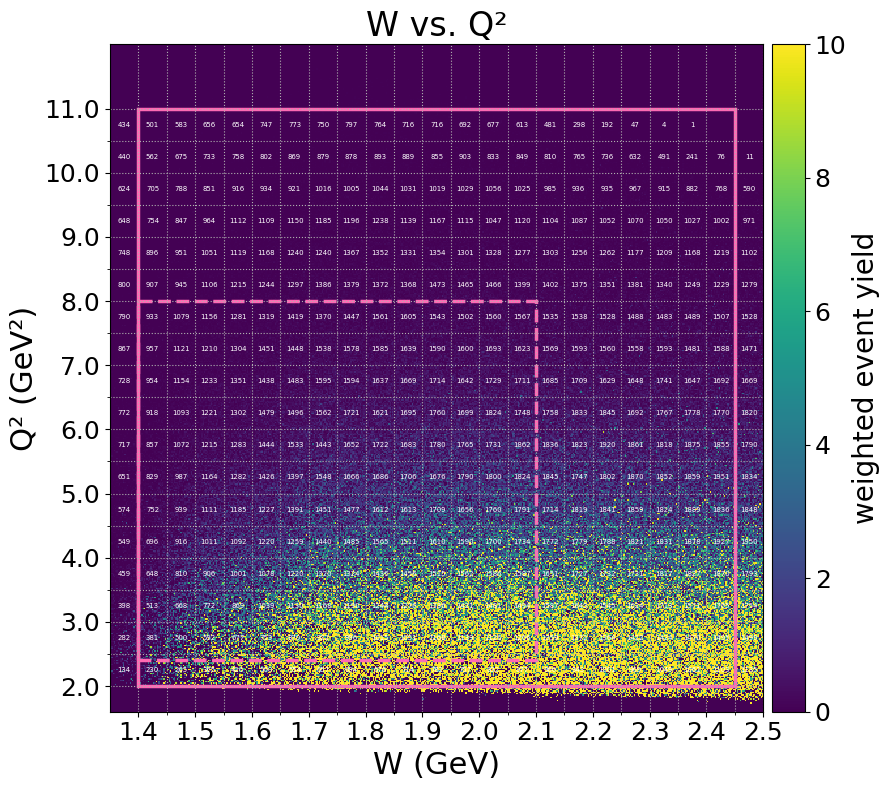

In [ ]:
w_range = np.append(np.arange(1.35, 2.5, 0.05), 2.5)

# ###### fine bins
n_w_bins  = 500  #500
n_q2_bins = 500

w_min, w_max   = 1.35, 2.50
# q2_min, q2_max = 1.6, 12.0
# q2_min, q2_max = 1.6, 30.0

# --- W vs Q² histograms with colorbars for each topology ---
fine_bin_x = np.linspace(w_min, w_max, n_w_bins + 1)
fine_bin_y = np.linspace(q2_min, q2_max, n_q2_bins + 1)

df = sim_rec_dataset

# for topo in topologies:
fig, ax = plt.subplots(figsize=(9, 8))
mask = df["w"].notna() & df["q2"].notna() & (df["w"] >= w_min) & (df["w"] <= w_max) & (df["q2"] >= q2_min) & (df["q2"] <= q2_max)
w_vals = df.loc[mask, "w"].to_numpy()
q2_vals = df.loc[mask, "q2"].to_numpy()
weights = df.loc[mask, "weight"].to_numpy()
colorbar_max = 10

# 2D histogram — color represents event density
# h = ax.hist2d(w_vals, q2_vals, bins=[fine_bin_x, fine_bin_y], cmap='viridis', cmin=1E-300, weights=weights, density=False)
h = ax.hist2d(w_vals, q2_vals, bins=[fine_bin_x, fine_bin_y], cmap='viridis', cmin=0, weights=weights, vmax=colorbar_max, density=False)

# Count events in the analysis W-Q² bins (unweighted)
count_hist, _, _ = np.histogram2d(
    w_vals,
    q2_vals,
    bins=[w_range, bin_y]
)

# Add event counts to the plot
for i in range(len(w_range) - 1):
    for j in range(len(bin_y) - 1):

        count = int(count_hist[i, j])

        # Only label bins that actually contain events
        if count > 0:
            w_center = 0.5 * (w_range[i] + w_range[i+1])
            q2_center = 0.5 * (bin_y[j] + bin_y[j+1])

            ax.text(
                w_center,
                q2_center,
                f"{count}",
                ha="center",
                va="center",
                fontsize=5,
                color="white"
                path_effects=[
                    pe.withStroke(linewidth=1.2, foreground="black")
                ]
            )

# Title and axes
ax.set_title(f"W vs. Q²", fontsize=24)
ax.set_xlabel("W (GeV)", fontsize=22)
ax.set_ylabel("Q² (GeV²)", fontsize=22)

# Colorbar setup
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h[3], cax=cax)
# cb = plt.colorbar(h, cax=cax)
cb.set_label("weighted event yield", fontsize=20)
cb.ax.tick_params(labelsize=18)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(np.arange(1.4, 2.51, 0.05), minor=True) 
ax.set_yticks(major_yticks)
ax.set_yticks(bin_y, minor=True)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


# Define analyzed range
w_min_analyzed, w_max_analyzed = 1.4, 2.45
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

# Create a red rectangle
rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),  # bottom-left corner
    w_max_analyzed - w_min_analyzed,    # width
    q2_max_analyzed - q2_min_analyzed,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, facecolor='none')

# Define analyzed range
w_min_analyzed_krishna, w_max_analyzed_krishna = 1.4, 2.10
q2_min_analyzed_krishna, q2_max_analyzed_krishna = 2.4, 8.0

# Create a red rectangle
rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),  # bottom-left corner
    w_max_analyzed_krishna - w_min_analyzed_krishna,    # width
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, linestyle='--', facecolor='none')

# Add rectangle to the axes
ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

## acceptance

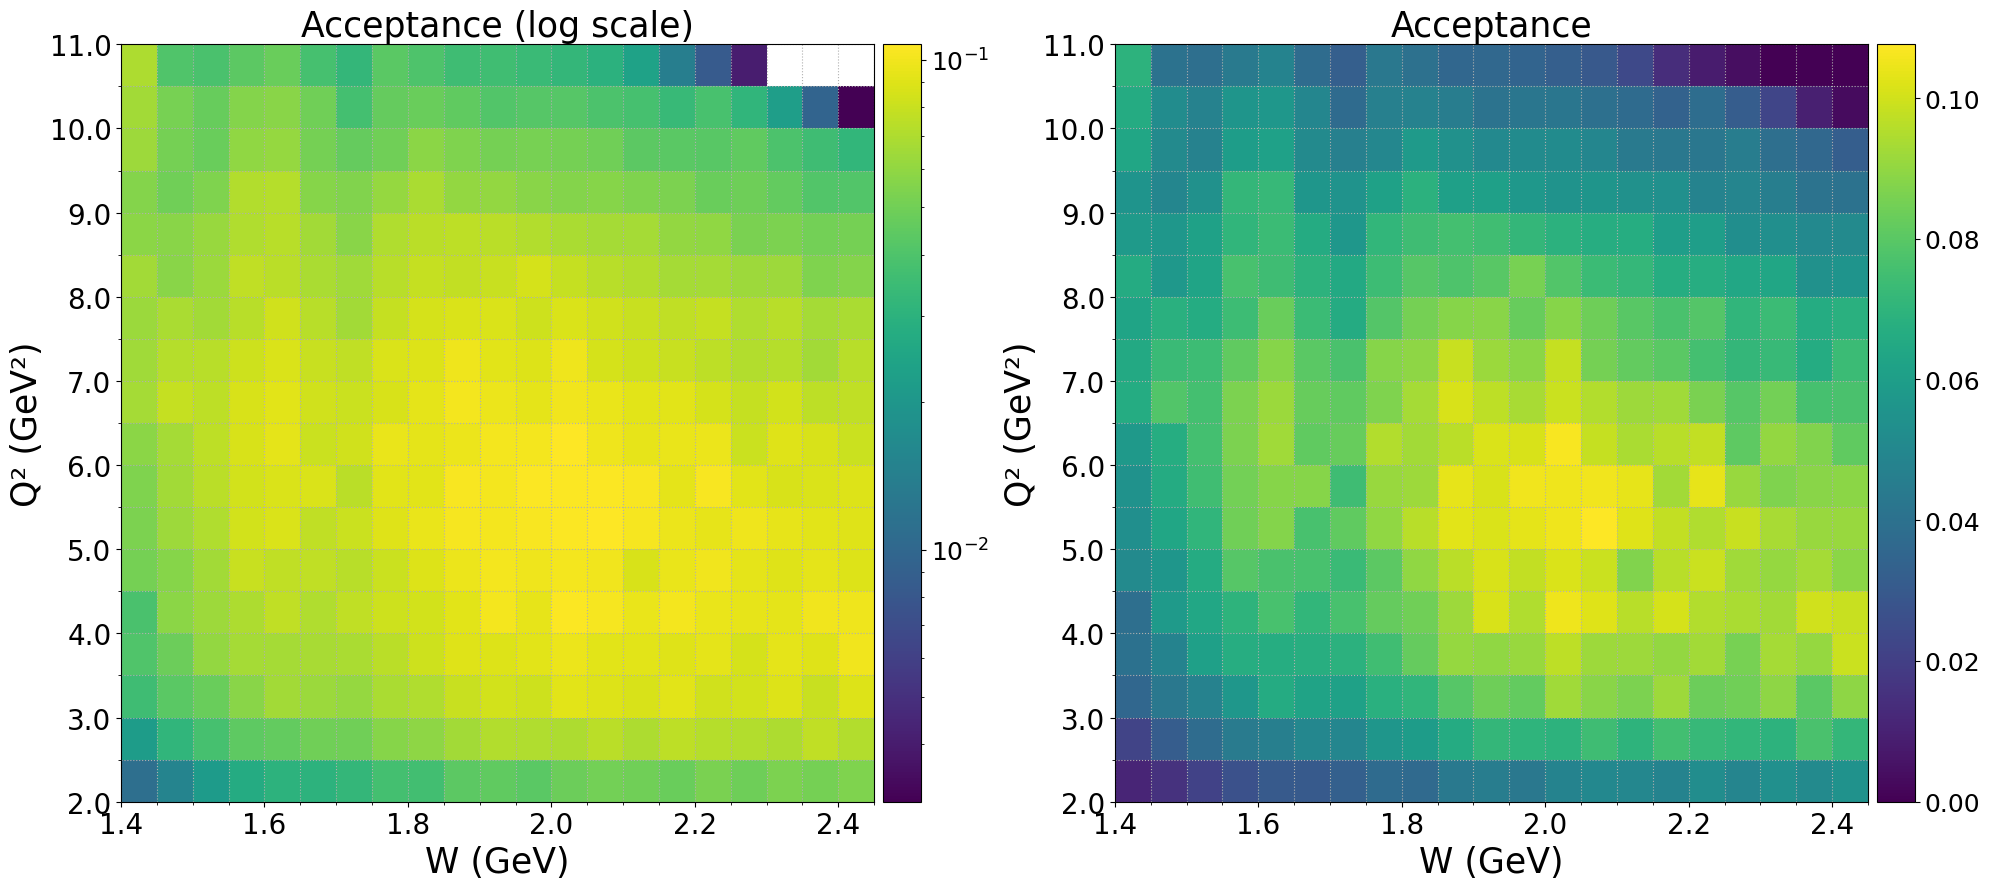

In [172]:
# Plot Acceptance: 10.6 GeV
def plot_acceptance(ax, data, log_norm=False, title=""):
    hist = ax.hist2d(
        data.w_val.to_numpy(),
        data.q2_val.to_numpy(),
        bins=[bin_x, bin_y],
        cmap='viridis', #inferno
        density=False,
        cmin=0,
        norm=mpl.colors.LogNorm() if log_norm else None,
        weights=data.acceptance
    )

    # Labels / format
    ax.set_title(title, fontsize=25)
    ax.set_xlabel("W (GeV)", fontsize=25)
    ax.set_ylabel("Q² (GeV²)", fontsize=25)
    ax.tick_params(axis='both', which='both', labelsize=20)

    # grid
    # ax.set_xticks(np.arange(1.4, 2.45, 0.1))
    ax.set_xticks(bin_x, minor=True)
    # ax.set_yticks(np.arange(2.0, 11.1, 0.5), minor=True)
    ax.set_yticks(bin_y, minor=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    # ax.set_yticks(bin_y)

    # ax.set_xlim(1.4, 2.45)
    # ax.set_ylim(2.0, 11.0) 
    # ax.set_ylim(2.0, 22.0) 
    ax.grid(which='both', linestyle=':')

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.09)
    cbar = plt.colorbar(hist[3], cax=cax)
    cbar.ax.tick_params(labelsize=18)  # <--- adjust numeric labels

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_acceptance(axes[0], sim_calc, log_norm=True, title="Acceptance (log scale)")
plot_acceptance(axes[1], sim_calc, log_norm=False, title="Acceptance")

plt.tight_layout()
plt.show()


## integrated cross section

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_74842/2837658012.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('10.6 GeV: Integrated Hadronic Cross-Section ($\mu$b)', fontsize=20)
/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_74842/2837658012.py:34: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma$ ($\mu$b)', fontsize=18)


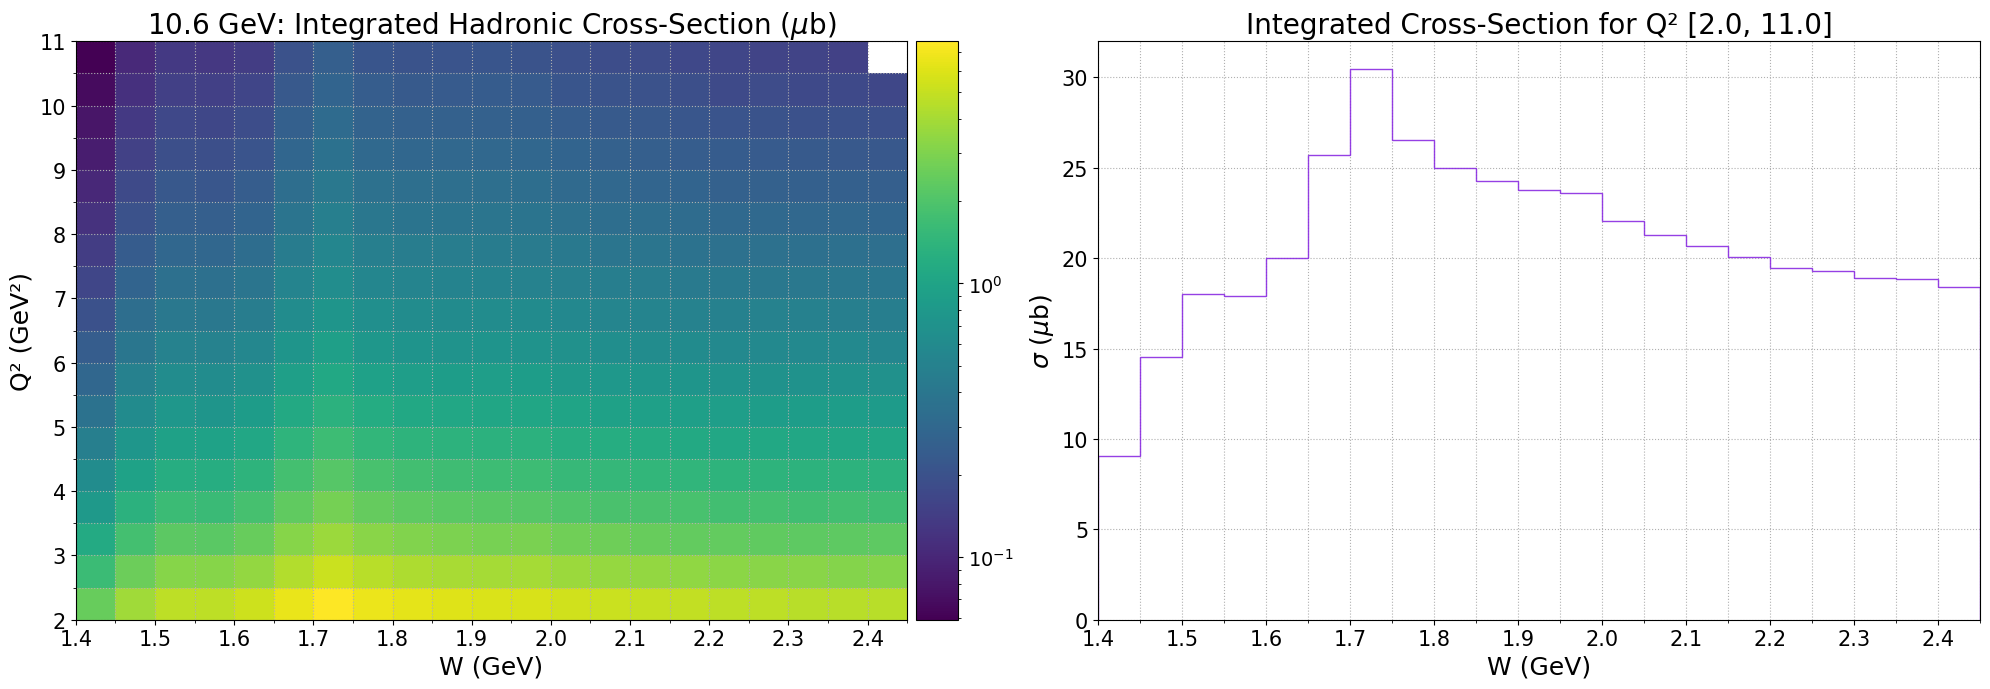

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ----------- LEFT: 2D integrated cross section
ax = axes[0]
hist = ax.hist2d(sim_calc.w_val.to_numpy(), sim_calc.q2_val.to_numpy(), 
                 bins=[bin_x, bin_y], cmap='viridis', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=sim_calc.cs_scaled)

ax.set_title('10.6 GeV: Integrated Hadronic Cross-Section ($\mu$b)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('Q² (GeV²)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(major_yticks)
ax.set_yticks(bin_y, minor=True)
ax.set_xlim(1.4, 2.45)
# ax.set_ylim(2.0, 22.0) 
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)

# ----------- RIGHT: W-projected cross section
ax = axes[1]
ax.hist(sim_calc.w_val.to_numpy(), range=(1.4, 2.5), bins=bin_x, weights=sim_calc.cs_scaled, histtype='step', alpha=0.9, color='blueviolet')

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

ax.set_title('Integrated Cross-Section for Q² [2.0, 11.0]', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('$\sigma$ ($\mu$b)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_xlim(1.4, 2.45)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()


In [130]:
# ============================================================
# W scale factors from krishna
# Rows    = Q² bins
# Columns = W bins
# ============================================================

twopeg_W_scale_factors = np.array([
    [1.004211, 1.148794, 0.989093, 0.922634, 0.899489, 0.992955, 1.023289, 0.915766, 0.929878, 0.987731, 0.943487, 0.926322, 0.909633, 0.841183],

    [0.815422, 0.927827, 0.898250, 0.819461, 0.837215, 0.953629, 1.071787, 0.970500, 0.978268, 1.048198, 1.053690, 0.989108, 0.961490, 0.905667],

    [0.986176, 0.981531, 0.913725, 0.876044, 0.938181, 1.009985, 1.131275, 1.021808, 1.002267, 1.123299, 1.121798, 1.055486, 1.049308, 0.929179],

    [1.005047, 0.995475, 1.005265, 0.922833, 0.982457, 1.087645, 1.204002, 1.080880, 1.081616, 1.132415, 1.072460, 1.027363, 0.992088, 0.917982],

    [1.005536, 0.978511, 0.865748, 0.766142, 0.916022, 0.969819, 1.080374, 0.990487, 0.963121, 1.038411, 1.055719, 1.043408, 1.001927, 0.958459],

    [1.307788, 1.040652, 0.921352, 0.854077, 0.954695, 0.902797, 1.045428, 0.872150, 0.922488, 0.980257, 0.924563, 0.915225, 0.942118, 0.905425],

    [0.941066, 1.037920, 0.810638, 0.781193, 0.922739, 0.895750, 0.925064, 1.049887, 0.952149, 0.938898, 1.000741, 0.885873, 0.986096, 0.871332],

    [0.720877, 0.916051, 0.762204, 0.816070, 0.865472, 0.985150, 1.105986, 1.014232, 0.975946, 1.061765, 1.053227, 1.036501, 1.032657, 1.181062]
])

In [131]:
histogram_folder = Path(hist_base_path) / 'cross_sections'
histogram_folder.mkdir(parents=True, exist_ok=True)

major_xticks = np.arange(1.4, 2.451, 0.1)

# Loop over Q² bins
for i in range(len(bin_y) - 1):

    q2_min = bin_y[i]
    q2_max = bin_y[i + 1]

    # Select this Q² bin
    if i == len(bin_y) - 2:
        mask = (
            (sim_calc.q2_val >= q2_min) &
            (sim_calc.q2_val <= q2_max)
        )
    else:
        mask = (
            (sim_calc.q2_val >= q2_min) &
            (sim_calc.q2_val < q2_max)
        )

    data = sim_calc[mask]

    # Skip empty Q² bins
    if len(data) == 0:
        continue

    # W values are already the centers of the W bins
    w_vals = data.w_val.to_numpy()
    cs_scaled_vals = data.cs_scaled.to_numpy()
    cs_scaled_krishna_vals = data.cs_scaled_krishna.to_numpy()
    cs_vals = data.cross_section.to_numpy()
    cs_scaled_unc = data.cs_scaled_unc.to_numpy()
    cs_scaled_krishna_unc = data.cs_scaled_krishna_unc.to_numpy()

    # # ============================================================
    # # Apply W scaling where scale factors are available
    # # ============================================================

    # # Start with Q²-scaled values unchanged
    # cs_scaled_w_vals = cs_scaled_vals.copy()
    # cs_scaled_w_unc = cs_scaled_unc.copy()

    # # Number of W scale factors available for this Q² bin
    # n_w_factors = twopeg_W_scale_factors.shape[1]

    # # Number of W points actually present
    # n_w_points = len(w_vals)

    # # Only apply W scaling where BOTH:
    # #   1. a W scale factor exists for this Q² bin
    # #   2. a corresponding W point exists
    # if i < twopeg_W_scale_factors.shape[0]:

    #     n_to_scale = min(n_w_points, n_w_factors)

    #     w_factors = twopeg_W_scale_factors[i, :n_to_scale]

    #     # Apply W scaling AFTER Q²/form-factor scaling
    #     cs_scaled_w_vals[:n_to_scale] *= w_factors

    #     # Scale statistical uncertainties by the same factor
    #     cs_scaled_w_unc[:n_to_scale] *= w_factors

    # ============================================================
    # Apply W scaling only where a W scale factor exists
    # ============================================================

    # Start with Q²-scaled values unchanged.
    # Any W bin without a W scale factor will remain this way.
    cs_scaled_w_vals = cs_scaled_krishna_vals.copy()
    cs_scaled_w_unc = cs_scaled_krishna_unc.copy()

    # W-bin centers corresponding to the columns of the W scale-factor table
    w_factor_centers = (bin_x[:-1] + bin_x[1:]) / 2

    # Only apply W scaling if a scale-factor row exists for this Q² bin
    if i < twopeg_W_scale_factors.shape[0]:

        for j, w_val in enumerate(w_vals):

            # Find the W-bin corresponding to this point
            w_match = np.where(np.isclose(w_factor_centers, w_val, atol=1e-6))[0]

            # If this W bin has a W scale factor, apply it
            if len(w_match) > 0 and w_match[0] < twopeg_W_scale_factors.shape[1]:

                w_index = w_match[0]
                w_factor = twopeg_W_scale_factors[i, w_index]

                cs_scaled_w_vals[j] *= w_factor
                cs_scaled_w_unc[j] *= w_factor

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    # fig, ax = plt.subplots(figsize=(8, 6))
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.errorbar(w_vals, cs_scaled_w_vals, yerr=cs_scaled_w_unc, fmt='o', color='orange', markersize=4, capsize=3, elinewidth=1, linestyle='none', label='TWOPEG Q² + W scaled*')
    # ax.errorbar(w_vals, cs_scaled_vals, yerr=cs_scaled_unc, fmt='o', color='blueviolet', markersize=3, capsize=3, elinewidth=1, linestyle='none', label='TWOPEG scaled v1')
    ax.errorbar(w_vals, cs_scaled_krishna_vals, yerr=cs_scaled_krishna_unc, fmt='o', color='green', markersize=4, capsize=3, elinewidth=1, linestyle='none', label='TWOPEG Q² scaled')
    ax.errorbar(w_vals, cs_vals, yerr=cs_unc, fmt='o', color='red', markersize=4, capsize=3, elinewidth=1, linestyle='none', label='TWOPEG')
    ax.legend(fontsize=12, loc='best')
    ax.set_xlim(bin_x[0], bin_x[-1])

    # Labels
    ax.set_title(f'Int. CS for Q² [{q2_min:.2f}, {q2_max:.2f}] GeV²', fontsize=18)
    ax.set_xlabel('W (GeV)', fontsize=18)
    ax.set_ylabel(r'$\sigma$ (μb)', fontsize=18)

    # Ticks and grid
    # ax.set_xticks(major_xticks)
    # ax.set_xticks(bin_x, minor=True)

    # ax.set_xlim(1.4, 2.45)

    # Ticks and grid

    # Major ticks every 0.1
    major_xticks = np.arange(1.4, 2.451, 0.1)

    # Keep all major grid lines
    ax.set_xticks(major_xticks)

    # Only label every other major tick
    xlabels = [
        f"{x:.1f}" if i % 2 == 0 else ""
        for i, x in enumerate(major_xticks)
    ]

    ax.set_xticklabels(xlabels)

    # Minor ticks/grid every W bin
    ax.set_xticks(bin_x, minor=True)

    ax.set_xlim(1.4, 2.45)

    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=15)

    # Save
    filename = f'cs_Q2_{q2_min:.2f}_{q2_max:.2f}.png'

    plt.tight_layout()
    plt.savefig(histogram_folder / filename, dpi=300)
    plt.close(fig)

## luminosity

In [132]:
print("bin_x max =", bin_x[-1])
print("major_xticks max =", max(major_xticks))


bin_x max = 2.450000000000001
major_xticks max = 2.400000000000001


/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_74842/3580900624.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)


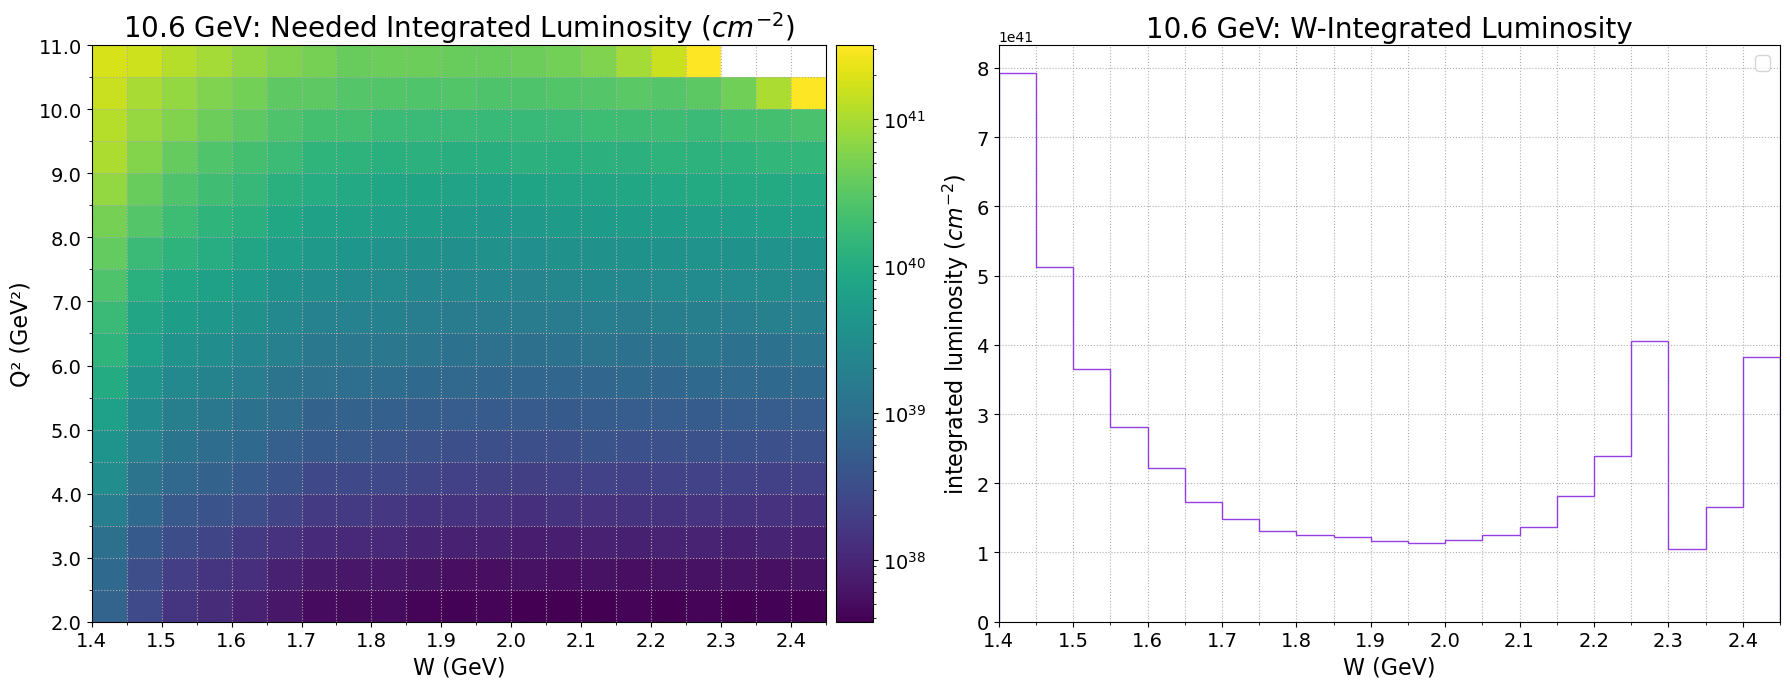

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))  # left and right panels

# ----------- LEFT: 2D luminosity
ax = axes[0]
hist = ax.hist2d(sim_calc.w_val.to_numpy(), sim_calc.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='viridis', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=sim_calc.lumi_elec)

ax.set_title('10.6 GeV: Needed Integrated Luminosity ($cm^{-2}$)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(major_yticks)
ax.set_yticks(bin_y, minor=True)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

# Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Integrated Luminosity ($cm^{-2}$)', fontsize=16)

# ----------- RIGHT: 1D luminosity (projection on W)
ax = axes[1]
ax.hist(sim_calc.w_val.to_numpy(), bins=bin_x, weights=sim_calc.lumi_elec, histtype='step', alpha=0.9, color='blueviolet')

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

ax.set_title('10.6 GeV: W-Integrated Luminosity', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('integrated luminosity ($cm^{-2}$)', fontsize=16)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
# ax.grid(which='major', linestyle='-', linewidth=1)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()


In [134]:
# Folder for per-Q² luminosity histograms
luminosity_folder = Path(hist_base_path) / 'luminosity'

luminosity_folder.mkdir(parents=True, exist_ok=True)

major_xticks = np.arange(1.4, 2.451, 0.1)

# Loop over Q² bins
for i in range(len(bin_y) - 1):

    q2_min = bin_y[i]
    q2_max = bin_y[i + 1]

    # Select this Q² bin
    if i == len(bin_y) - 2:
        mask = (
            (sim_calc.q2_val >= q2_min) &
            (sim_calc.q2_val <= q2_max)
        )
    else:
        mask = (
            (sim_calc.q2_val >= q2_min) &
            (sim_calc.q2_val < q2_max)
        )

    data = sim_calc[mask]

    # Skip empty Q² bins
    if len(data) == 0:
        continue

    # W values and luminosity
    w_vals = data.w_val.to_numpy()
    lumi_vals = data.lumi_elec.to_numpy()

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.hist(w_vals, bins=bin_x, weights=lumi_vals, histtype='step', alpha=0.9, color='blueviolet', linewidth=1.5, label='electron luminosity')

    # Axis limits
    ax.set_xlim(bin_x[0], bin_x[-1])

    # Labels
    ax.set_title(f'Integrated Luminosity for Q² [{q2_min:.2f}, {q2_max:.2f}] GeV²', fontsize=18)
    ax.set_xlabel('W (GeV)', fontsize=18)
    ax.set_ylabel(r'integrated luminosity ($cm^{-2}$)', fontsize=18)

    # ---------------------------------------------------------
    # Ticks and grid
    # ---------------------------------------------------------

    # Major ticks every 0.1 GeV
    ax.set_xticks(major_xticks)

    # Label every other major tick
    xlabels = [f"{x:.1f}" if j % 2 == 0 else "" for j, x in enumerate(major_xticks)]

    ax.set_xticklabels(xlabels)

    # Minor ticks at every W bin
    ax.set_xticks(bin_x, minor=True)
    ax.set_xlim(1.4, 2.45)
    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.legend(fontsize=12, loc='best')

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------

    filename = f'lumi_Q2_{q2_min:.2f}_{q2_max:.2f}.png'

    plt.tight_layout()
    plt.savefig(luminosity_folder / filename, dpi=300)
    plt.close(fig)

## charge

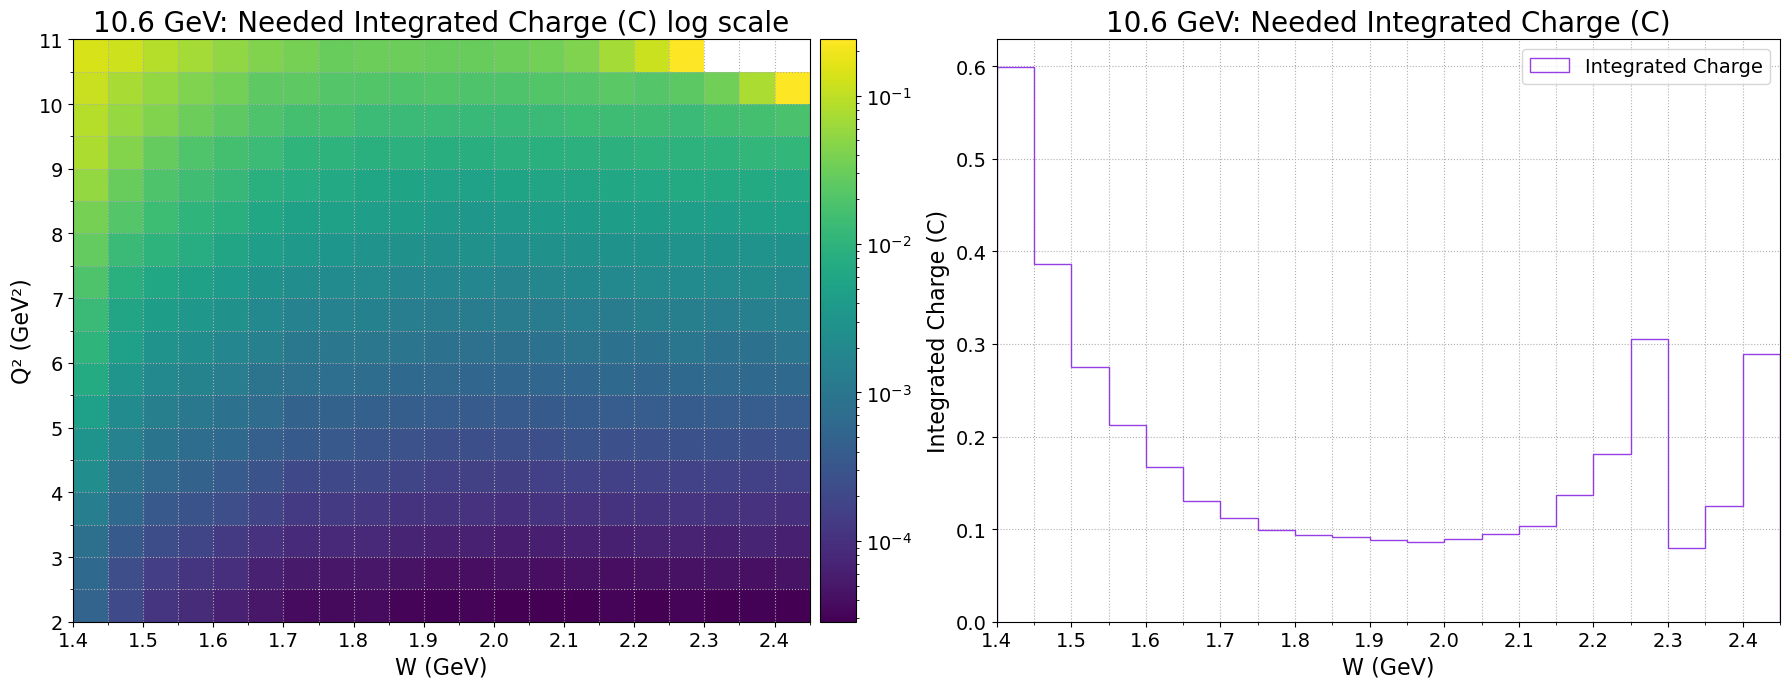

In [135]:
# Figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ----------- LEFT: log scale
ax = axes[0]
hist = ax.hist2d(sim_calc.w_val.to_numpy(), sim_calc.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='viridis', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=sim_calc.q_elec)

ax.set_title('10.6 GeV: Needed Integrated Charge (C) log scale', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(major_yticks)
ax.set_yticks(bin_y, minor=True)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Integrated Charge (C)', fontsize=14)

# ----------- RIGHT: linear scale
ax = axes[1]
# 1D histogram of integrated charge vs W
ax.hist(
    sim_calc.w_val.to_numpy(),
    bins=bin_x,
    range=(1.4, 2.5),
    weights=sim_calc.q_elec,
    histtype='step',
    alpha=0.9,
    color='blueviolet',
    label='Integrated Charge'
)

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

# Labels
ax.set_title('10.6 GeV: Needed Integrated Charge (C)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Integrated Charge (C)', fontsize=16)

# Ticks
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.tick_params(axis='both', which='major', labelsize=14)

# Grid
ax.grid(which='both', linestyle=':')

# Legend
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()



## time

/var/folders/wd/z4b9mvxs2xb0v8hc2svy1l580000gp/T/ipykernel_74842/2792782128.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)


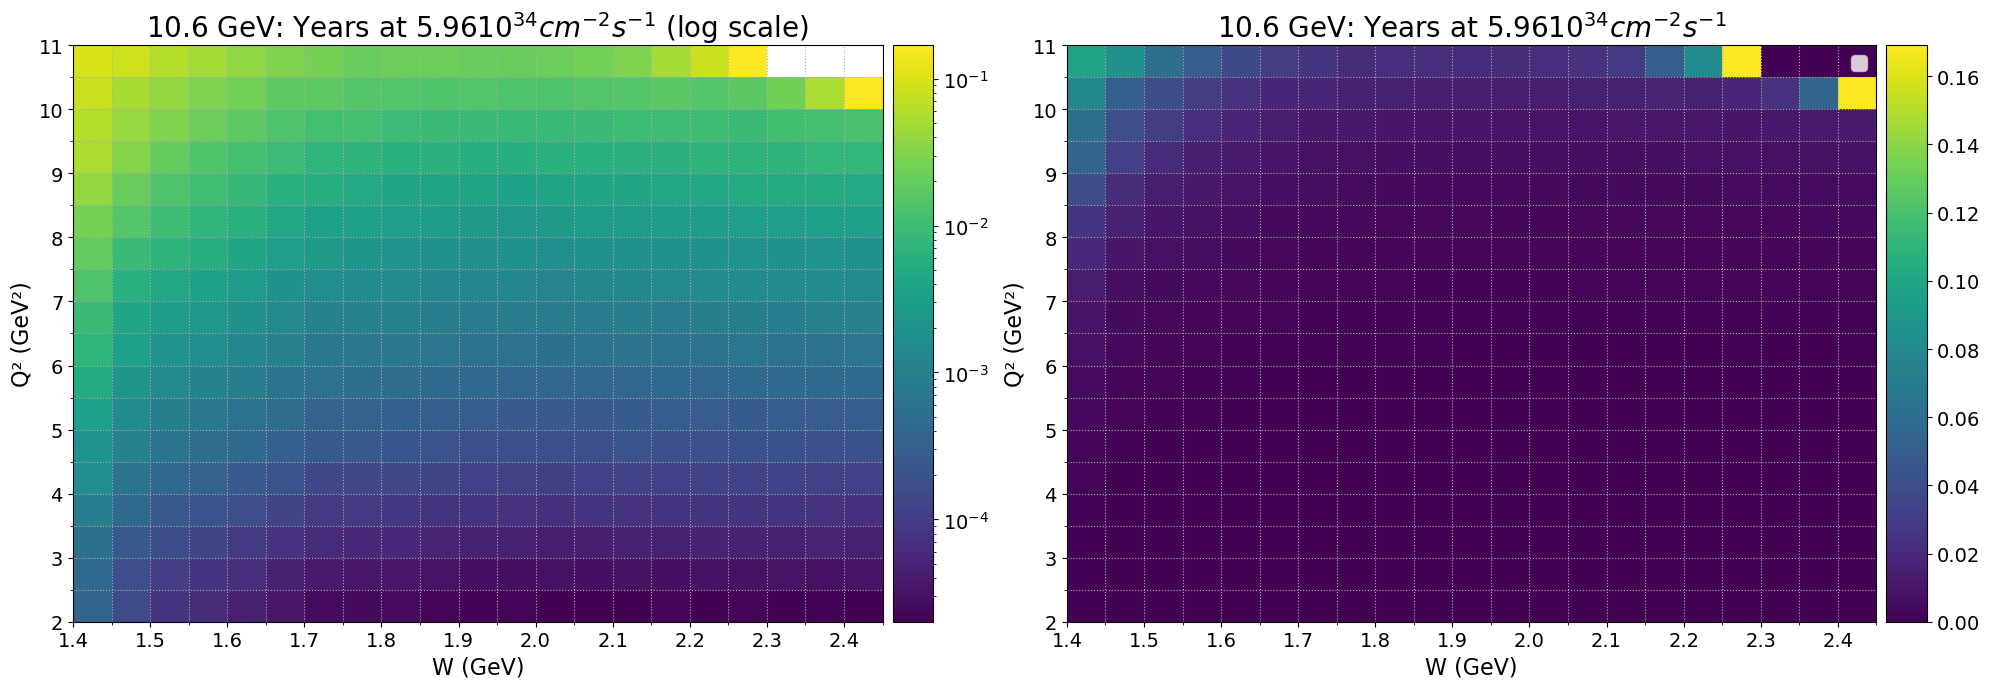

In [136]:
# Figure
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ---------------- LEFT: 2D log scale ----------------
ax = axes[0]
hist = ax.hist2d(sim_calc.w_val.to_numpy(), sim_calc.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='viridis', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=sim_calc.no_year_45nA)

# Labels
ax.set_title('10.6 GeV: Years at $5.96 10^{34} cm^{-2} s^{-1}$ (log scale)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)

# Ticks & Grid
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(major_yticks)
ax.set_yticks(bin_y, minor=True)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

# Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Years', fontsize=14)

# ---------------- RIGHT: 1D linear scale ----------------
# ax = axes[1]
# ax.hist(
#     sim_calc.w_val.to_numpy(),
#     bins=bin_x,
#     range=(1.4, 2.5),
#     weights=sim_calc.no_year_45nA,
#     histtype='step',
#     color='blueviolet',
#     alpha=0.9,
#     label='W-integrated Years'
# )

# # Labels
# ax.set_title('10.6 GeV: W-Integrated Years (linear scale)', fontsize=20)
# ax.set_xlabel('W (GeV)', fontsize=16)
# ax.set_ylabel('Years', fontsize=16)

# # Ticks & Grid
# ax.set_xticks(major_xticks)
# ax.set_xticks(bin_x, minor=True)
# ax.tick_params(axis='both', which='major', labelsize=14)
# ax.grid(which='both', linestyle=':')

ax = axes[1]
hist = ax.hist2d(sim_calc.w_val.to_numpy(), sim_calc.q2_val.to_numpy(),
    bins=[bin_x, bin_y], cmap='viridis', density=False, cmin=0, weights=sim_calc.no_year_45nA)

# Labels
ax.set_title('10.6 GeV: Years at $5.96 10^{34} cm^{-2} s^{-1}$', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=16)
ax.set_ylabel('Q² (GeV²)', fontsize=16)

# Ticks & Grid
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(major_yticks)
ax.set_yticks(bin_y, minor=True)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(which='both', linestyle=':')

# Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Years', fontsize=14)

# Legend
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()


# for exp data

In [ ]:
## change all gen stuff to exp

exp_10_6GeV = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/exp/10_6exp_excl_jlab_11_09_2025.csv", index_col=False)
exp_10_6GeV = exp_10_6GeV[(exp_10_6GeV.weight>0.0)]

hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists/experiment/EXCL_topology')

In [ ]:
# checking that my files read in correctly
exp_10_6GeV.head(14)

In [ ]:
exp_10_6GeV["weight"] = 1.0
exp_10_6GeV.head(6)

In [ ]:
# remove event colummn now
exp_10_6GeV.drop(columns=['event'], inplace=True, errors='ignore')


## define w-q2 bins

In [ ]:
# w-q2 ranges
bin_x = np.arange(1.4, 2.45, 0.05)
bin_y = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,12.0]

major_xticks = np.round(np.arange(1.4, 2.45 + 1e-6, 0.1), 2)

In [ ]:
# find number of exp events in each w-q2 bin from 10.6 GeV simulations (w and q2 are my x and y values)
def calcFunc(df):
    exp=df

    with open('output_10_6_exp.csv', mode='w') as out_file:
        out_binned_exclusive_writer = csv.writer(out_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        out_binned_exclusive_writer.writerow(['w_val','q2_val','exp_events' ,'flux','weight','cross_section','formfactor','cs_scaled'])
        NSIGMA = 4
        cut_data = {}
    
        # Make w bins
        w_bin_ranges = bin_x
        
        # Cuts the exp w data into the ranges from above
        exp['w_bin'] = pd.cut(exp.w, w_bin_ranges)
        # unique_w = exp.w_bin.unique()
        # unique_w = pd.Index.sort_values(unique_w)
        # unique_w = unique_w.dropna()
        unique_w = exp['w_bin'].cat.categories

        # Make q2 bins
        q2_bin_ranges = bin_y
        
        # Cuts the exp q2 data into the ranges from above
        exp['q2_bin'] = pd.cut(exp.q2, q2_bin_ranges)
        # unique_q2 = exp.q2_bin.unique()
        # unique_q2 = pd.Index.sort_values(unique_q2)
        # unique_q2 = unique_q2.dropna()
        unique_q2 = exp['q2_bin'].cat.categories

        
        # function to calculate virtual photon flux
        def flux(w,q2_value):
            E_beam = 10.6
            MASS_P = 0.938;
            PI = 3.14159265358979323846;

            omega = (w * w + q2_value - MASS_P * MASS_P) / (2. * MASS_P);

            en_elp = E_beam - omega;
            th_elp = 2 * math.asin(math.sqrt(q2_value / 4. / E_beam / en_elp));

            epsilon = 1 / (1. + 2. * (1. + omega * omega / q2_value) * (math.tan(th_elp / 2.)) * (math.tan(th_elp / 2.)));

            flux_calc = (omega - q2_value / 2. / MASS_P) / 137.;

            flux_calc = flux_calc / 2. / (PI) / E_beam / q2_value / (1 - epsilon);
            flux_calc = flux_calc * w / E_beam / MASS_P;

            return flux_calc;
             
        # go through each w-q2 bin
        for w in unique_w:
            for q2 in unique_q2:
                data = exp[(exp.w_bin == w) & (exp.q2_bin == q2)]
                w_val = (w.right+w.left)/2.0
                q2_val = (q2.right+q2.left)/2.0
                virtual_flux = flux(w_val,q2_val)
                ff_scale=(1/(1+(q2_val/0.7))**( 0.31660)) / ((1/(1+0.65/0.7))**(1.18085))
                index = data.index
                number_of_rows = len(index) 
                weight_sum=data['weight'].sum() # / 1e4  # divide weight by 10^4 for new weights by krishna ***this is done at the csv file creation level, not in the notebook
                cs = weight_sum/(number_of_rows*virtual_flux)
                cs_scaled = cs* ff_scale
                
                out_binned_exclusive_writer.writerow([w_val, q2_val, number_of_rows, 
                                                          "{:.5f}".format(virtual_flux), 
                                                          "{:.5f}".format(weight_sum), 
                                                          "{:.5f}".format(cs), 
                                                          "{:.5f}".format(ff_scale), 
                                                          "{:.5f}".format(cs_scaled)])
                    
                print(w_val, ",", q2_val, ",", "{:.7f}".format(virtual_flux), ",", number_of_rows, ",", 
                      "{:.5f}".format(weight_sum), ",", "{:.5f}".format(cs), ",", "{:.5f}".format(ff_scale), ",", "{:.5f}".format(cs_scaled))

    return cut_data

In [ ]:
# calculations for 10.6 GeV generated events
my_output = calcFunc(exp_10_6GeV)

In [ ]:
hist_10_6_gev_exp=pd.read_csv('output_10_6_exp.csv',index_col=False)

In [ ]:
# display the first few rows to verify the results
print(hist_10_6_gev_exp.head(10))

## integrated cross section

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ----------- LEFT: 2D integrated cross section
ax = axes[0]
hist = ax.hist2d(hist_10_6_gev_exp.w_val.to_numpy(), hist_10_6_gev_exp.q2_val.to_numpy(), 
                 bins=[bin_x, bin_y], cmap='inferno', density=False, cmin=0, norm=mpl.colors.LogNorm(), weights=hist_10_6_gev_exp.cs_scaled)

ax.set_title('10.6 GeV: Integrated Hadronic Cross-Section ($\mu$b)', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('Q² (GeV²)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.set_yticks(bin_y)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cbar = plt.colorbar(hist[3], cax=cax)
cbar.ax.tick_params(labelsize=14)

# ----------- RIGHT: W-projected cross section
ax = axes[1]
ax.hist(hist_10_6_gev_exp.w_val.to_numpy(), range=(1.4, 2.5), bins=bin_x, weights=hist_10_6_gev_exp.cs_scaled, histtype='step', alpha=0.9, color='blueviolet')

ax.set_xlim(bin_x[0], bin_x[-1])  # <<< Force axis to match your bin range

ax.set_title('Integrated Cross-Section for Q² [2.0, 11.0]', fontsize=20)
ax.set_xlabel('W (GeV)', fontsize=18)
ax.set_ylabel('$\sigma$ ($\mu$b)', fontsize=18)
ax.set_xticks(major_xticks)
ax.set_xticks(bin_x, minor=True)
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()


In [ ]:
histogram_folder = Path(hist_base_path) / 'cross_sections'
histogram_folder.mkdir(parents=True, exist_ok=True)  # make folder if it doesn't exist

major_xticks = np.arange(1.4, 2.51, 0.1)

# Loop over Q² bins
for i in range(len(bin_y)-1):
    q2_min = bin_y[i]
    q2_max = bin_y[i+1]

    # Mask data for this Q² bin
    if i == len(bin_y)-2:  # include right edge for last bin
        mask = (hist_10_6_gev_exp.q2_val >= q2_min) & (hist_10_6_gev_exp.q2_val <= q2_max)
    else:
        mask = (hist_10_6_gev_exp.q2_val >= q2_min) & (hist_10_6_gev_exp.q2_val < q2_max)

    w_vals = hist_10_6_gev_exp.w_val[mask]
    cs_vals = hist_10_6_gev_exp.cs_scaled[mask]

    # Skip empty bins
    if len(w_vals) == 0:
        continue

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))  # more square-like

    # 1D histogram
    ax.hist(w_vals, bins=bin_x, weights=cs_vals, histtype='step', color='blueviolet', alpha=0.9)

    ax.set_xlim(bin_x[0], bin_x[-1])  # Force axis to match bin range

    # Labels
    ax.set_title(f'Integrated Cross Section for Q² [{q2_min:.2f}, {q2_max:.2f}] GeV²', fontsize=20)
    ax.set_xlabel('W (GeV)', fontsize=16)
    ax.set_ylabel('$\sigma$ (μb)', fontsize=16)

    # Ticks and grid
    ax.set_xticks(major_xticks)
    ax.set_xticks(bin_x, minor=True)
    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Save PNG
    filename = f'cs_Q2_{q2_min:.2f}_{q2_max:.2f}.png'
    plt.tight_layout()
    plt.savefig(histogram_folder / filename, dpi=300)
    plt.close(fig)
